# 🎓 Student Performance Prediction System
### Educational Data Mining · Fairness Audit · Ensemble ML · SHAP Explainability

**Dataset:** `student_habits_performance.csv` — 1,000 students, 15 features  
**Goal:** Predict Pass/Fail *before* end of term for early intervention  
**Pipeline:**
1. Exploratory Data Analysis (EDA)
2. Data Preprocessing (missing values, outliers, encoding)
3. Fairness Audit (Demographic Parity)
4. Feature Engineering
5. Class Imbalance Handling
6. Model Training — Random Forest + XGBoost
7. Decision Threshold Tuning
8. Evaluation (Classification Report, ROC-AUC, Confusion Matrix)
9. SHAP Explainability
10. Save Model Artefacts for Streamlit Dashboard

## 📦 Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from scipy import stats

from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    f1_score, precision_score, recall_score,
    RocCurveDisplay, ConfusionMatrixDisplay, precision_recall_curve
)
from sklearn.utils import resample
from sklearn.inspection import permutation_importance

# ── imblearn: oversampling INSIDE CV folds (prevents data leakage) ──
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler

# XGBoost
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
    print('XGBoost available')
except ImportError:
    from sklearn.ensemble import GradientBoostingClassifier as XGBClassifier
    HAS_XGB = False
    print('XGBoost not found - using GradientBoostingClassifier')

# SHAP
try:
    import shap
    HAS_SHAP = True
    print('SHAP available')
except ImportError:
    HAS_SHAP = False
    print('SHAP not found - feature-importance chart used instead')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 4)})

RANDOM_STATE = 42
print('\nAll imports successful')

XGBoost available
SHAP available

All imports successful


---
## 📂 Section 1 — Data Loading & Exploratory Data Analysis

We start by understanding what the raw data looks like — shape, data types, missing values, and distributions.

In [2]:
df_raw = pd.read_csv('student_habits_performance.csv')
print(f'Shape: {df_raw.shape}')
df_raw.head(10)

Shape: (1000, 16)


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4
5,S1005,24,Male,7.2,1.3,0.0,No,82.9,7.4,Fair,1,Master,Average,4,No,100.0
6,S1006,21,Female,5.6,1.5,1.4,Yes,85.8,6.5,Good,2,Master,Poor,4,No,89.8
7,S1007,21,Female,4.3,1.0,2.0,Yes,77.7,4.6,Fair,0,Bachelor,Average,8,No,72.6
8,S1008,23,Female,4.4,2.2,1.7,No,100.0,7.1,Good,3,Bachelor,Good,1,No,78.9
9,S1009,18,Female,4.8,3.1,1.3,No,95.4,7.5,Good,5,Bachelor,Good,10,Yes,100.0


In [3]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [4]:
print('=== Missing Values ===')
print(df_raw.isnull().sum()[df_raw.isnull().sum() > 0])

print('\n=== Duplicate Rows ===')
print(df_raw.duplicated().sum())

print('\n=== Numeric Summary ===')
df_raw.describe().round(2)

=== Missing Values ===
parental_education_level    91
dtype: int64

=== Duplicate Rows ===
0

=== Numeric Summary ===


,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,20.50,3.55,2.51,1.82,84.13,6.47,3.04,5.44,69.60
std,2.31,1.47,1.17,1.08,9.40,1.23,2.03,2.85,16.89
min,17.00,0.00,0.00,0.00,56.00,3.20,0.00,1.00,18.40
25%,18.75,2.60,1.70,1.00,78.00,5.60,1.00,3.00,58.48
50%,20.00,3.50,2.50,1.80,84.40,6.50,3.00,5.00,70.50
75%,23.00,4.50,3.30,2.52,91.02,7.30,5.00,8.00,81.32
max,24.00,8.30,7.20,5.40,100.00,10.00,6.00,10.00,100.00


### 1.1 Categorical Value Counts

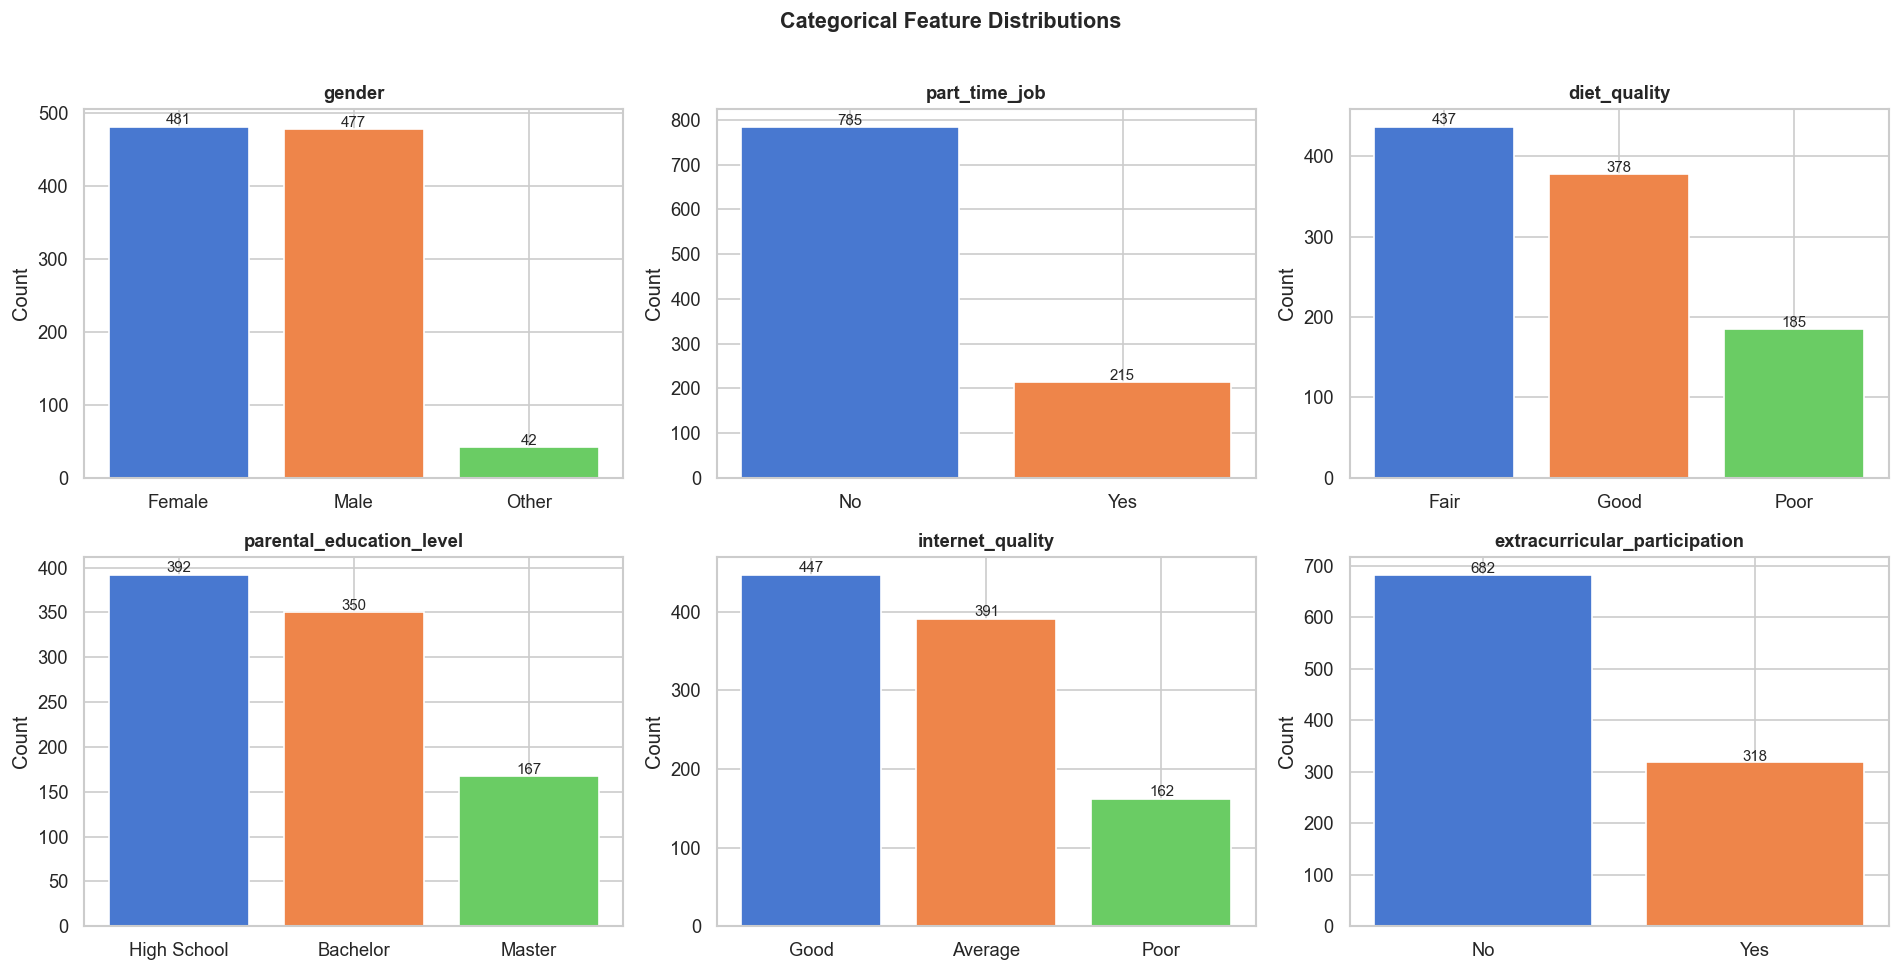

In [5]:
cat_cols = ['gender','part_time_job','diet_quality','parental_education_level',
            'internet_quality','extracurricular_participation']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    vc = df_raw[col].value_counts()
    axes[i].bar(vc.index, vc.values, color=sns.color_palette('muted', len(vc)))
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Count')
    for j, v in enumerate(vc.values):
        axes[i].text(j, v + 3, str(v), ha='center', fontsize=9)

plt.suptitle('Categorical Feature Distributions', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 1.2 Target Variable — Exam Score Distribution

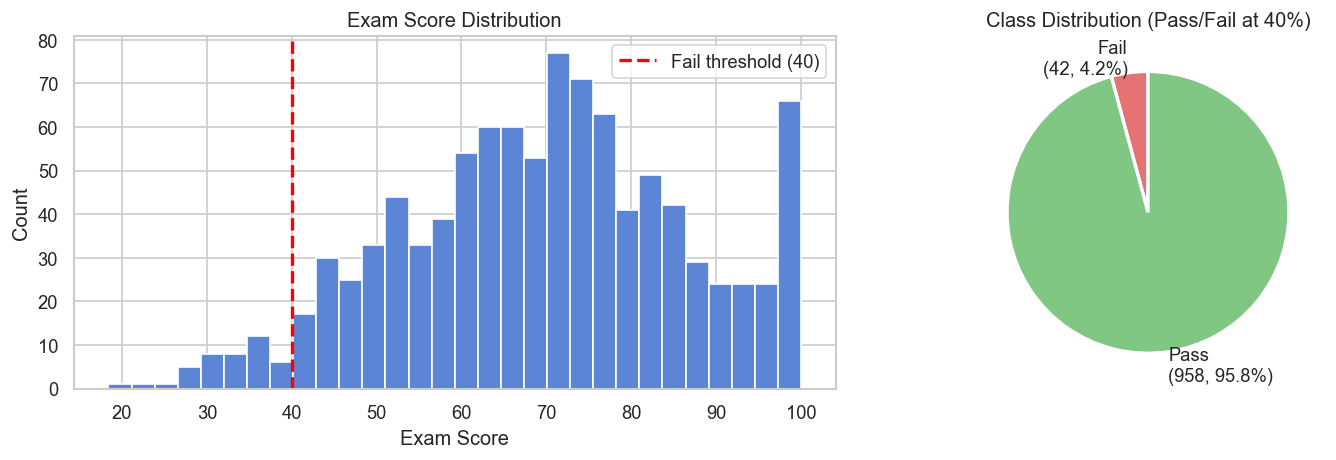

⚠️  Class imbalance: Fail=42 (4.2%) | Pass=958 (95.8%)
   Imbalance ratio 1:22 — must be addressed in training!


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram of exam scores
axes[0].hist(df_raw['exam_score'], bins=30, color='#5c85d6', edgecolor='white')
axes[0].axvline(40, color='red', linestyle='--', linewidth=2, label='Fail threshold (40)')
axes[0].set_xlabel('Exam Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Exam Score Distribution')
axes[0].legend()

# Pass vs Fail pie
fail_n = (df_raw['exam_score'] < 40).sum()
pass_n = (df_raw['exam_score'] >= 40).sum()
axes[1].pie([fail_n, pass_n],
            labels=[f'Fail\n({fail_n}, {fail_n/len(df_raw)*100:.1f}%)',
                    f'Pass\n({pass_n}, {pass_n/len(df_raw)*100:.1f}%)'],
            colors=['#e57373','#81c784'], startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Class Distribution (Pass/Fail at 40%)')

plt.tight_layout()
plt.show()

print(f'⚠️  Class imbalance: Fail={fail_n} ({fail_n/len(df_raw)*100:.1f}%) | Pass={pass_n} ({pass_n/len(df_raw)*100:.1f}%)')
print(f'   Imbalance ratio 1:{pass_n//fail_n} — must be addressed in training!')

### 1.3 Numeric Feature Distributions

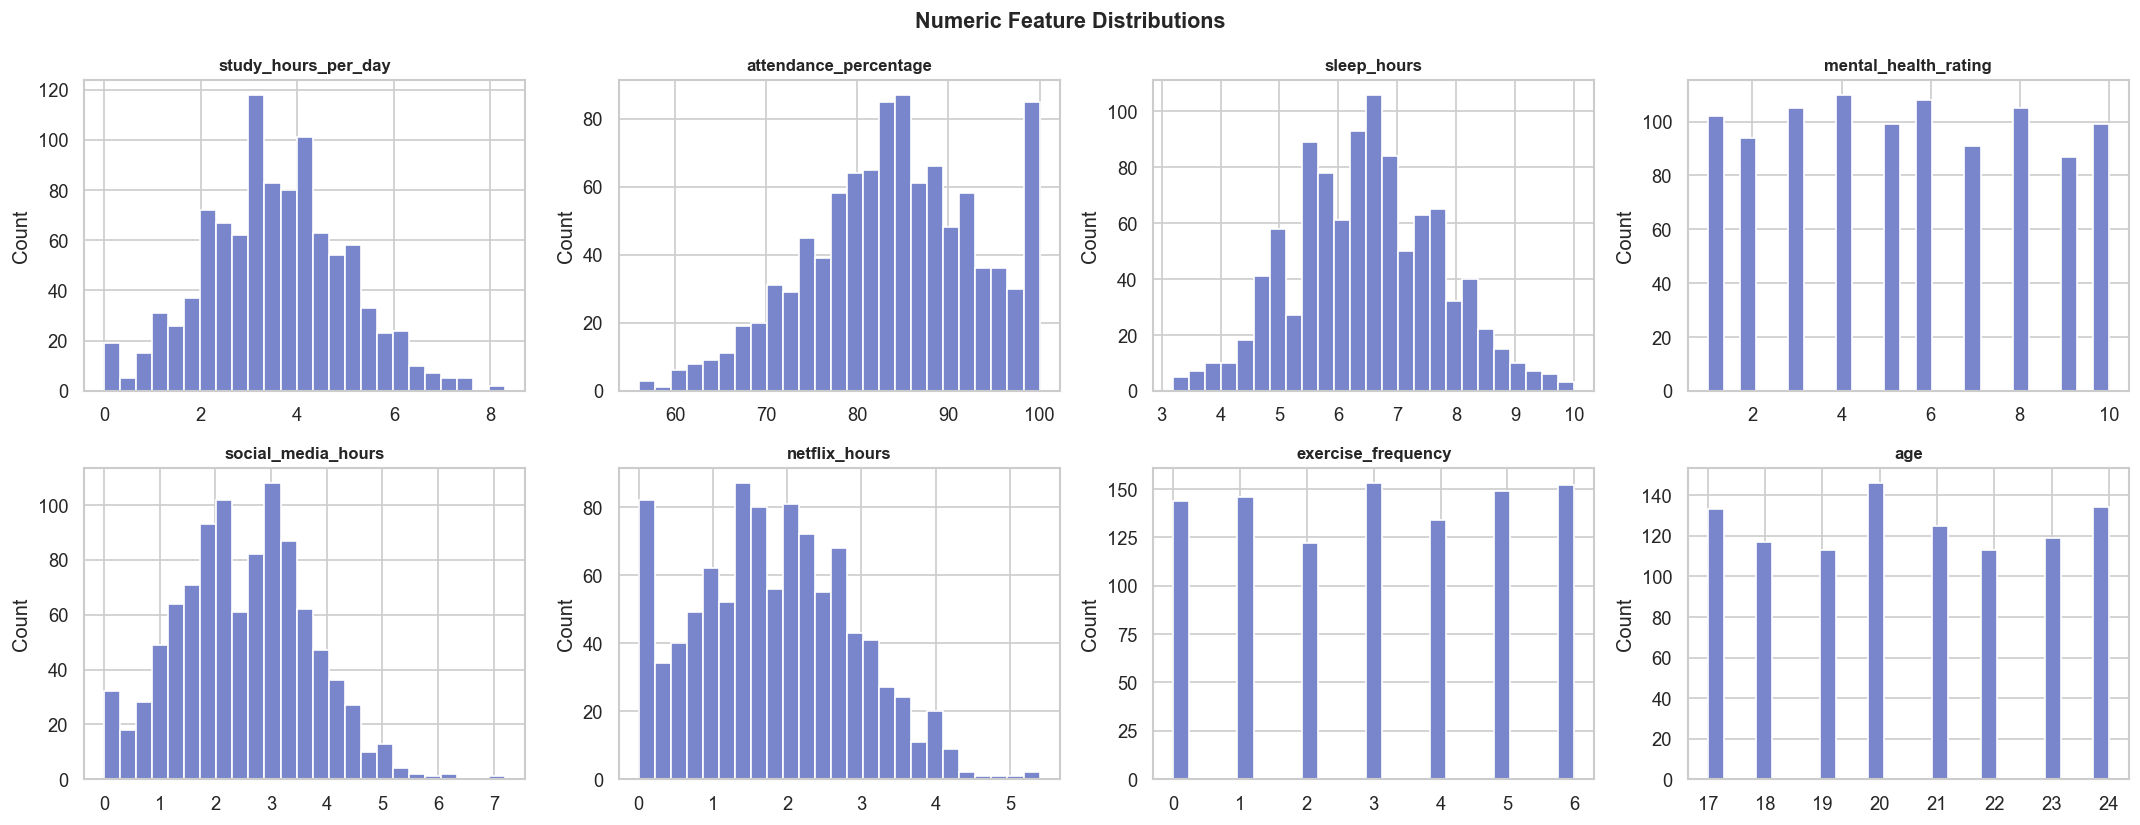

In [7]:
num_cols = ['study_hours_per_day','attendance_percentage','sleep_hours',
            'mental_health_rating','social_media_hours','netflix_hours',
            'exercise_frequency','age']

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df_raw[col], bins=25, color='#7986cb', edgecolor='white')
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Count')

plt.suptitle('Numeric Feature Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 1.4 Feature Correlation with Exam Score

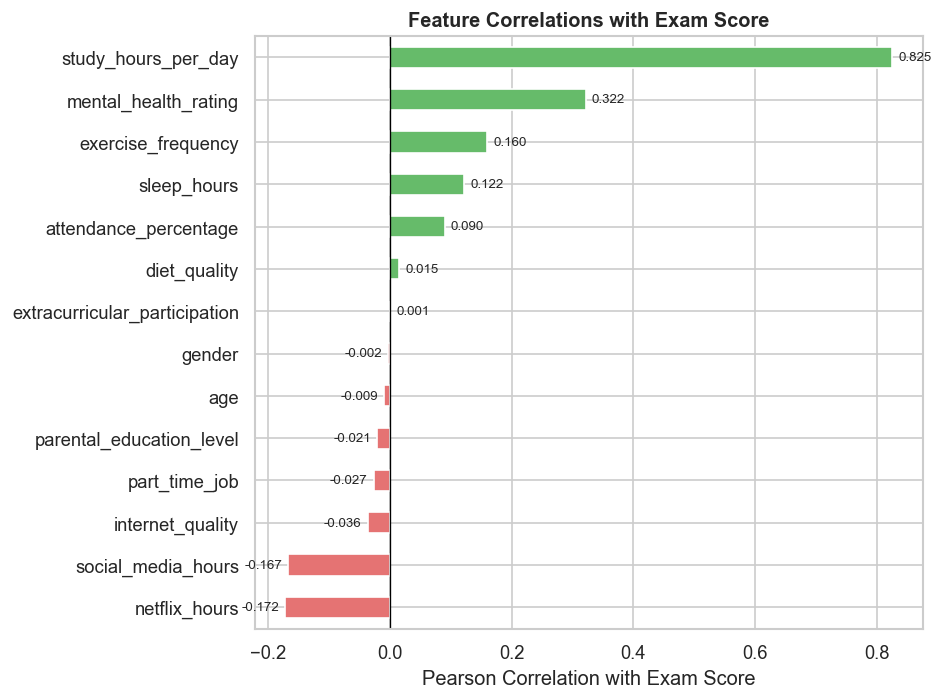

Top 3 positive predictors: ['exercise_frequency', 'mental_health_rating', 'study_hours_per_day']
Top 3 negative predictors: ['netflix_hours', 'social_media_hours', 'internet_quality']


In [8]:
df_enc = df_raw.copy()
df_enc.drop(columns=['student_id'], inplace=True)
df_enc['part_time_job'] = df_enc['part_time_job'].map({'No':0,'Yes':1})
df_enc['diet_quality'] = df_enc['diet_quality'].map({'Poor':0,'Fair':1,'Good':2})
df_enc['internet_quality'] = df_enc['internet_quality'].map({'Poor':0,'Average':1,'Good':2})
df_enc['extracurricular_participation'] = df_enc['extracurricular_participation'].map({'No':0,'Yes':1})
df_enc['parental_education_level'] = df_enc['parental_education_level'].map({'High School':0,'Bachelor':1,'Master':2})
df_enc['gender'] = df_enc['gender'].map({'Female':0,'Male':1,'Other':2})

corr = df_enc.corr()['exam_score'].drop('exam_score').sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#e57373' if v < 0 else '#66bb6a' for v in corr]
corr.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with Exam Score')
ax.set_title('Feature Correlations with Exam Score', fontweight='bold')
for i, (val, name) in enumerate(zip(corr, corr.index)):
    ax.text(val + (0.01 if val>=0 else -0.01), i, f'{val:.3f}',
            va='center', ha='left' if val>=0 else 'right', fontsize=8)
plt.tight_layout()
plt.show()

print('Top 3 positive predictors:', corr.tail(3).index.tolist())
print('Top 3 negative predictors:', corr.head(3).index.tolist())

### 1.5 Correlation Heatmap (All Numeric Features)

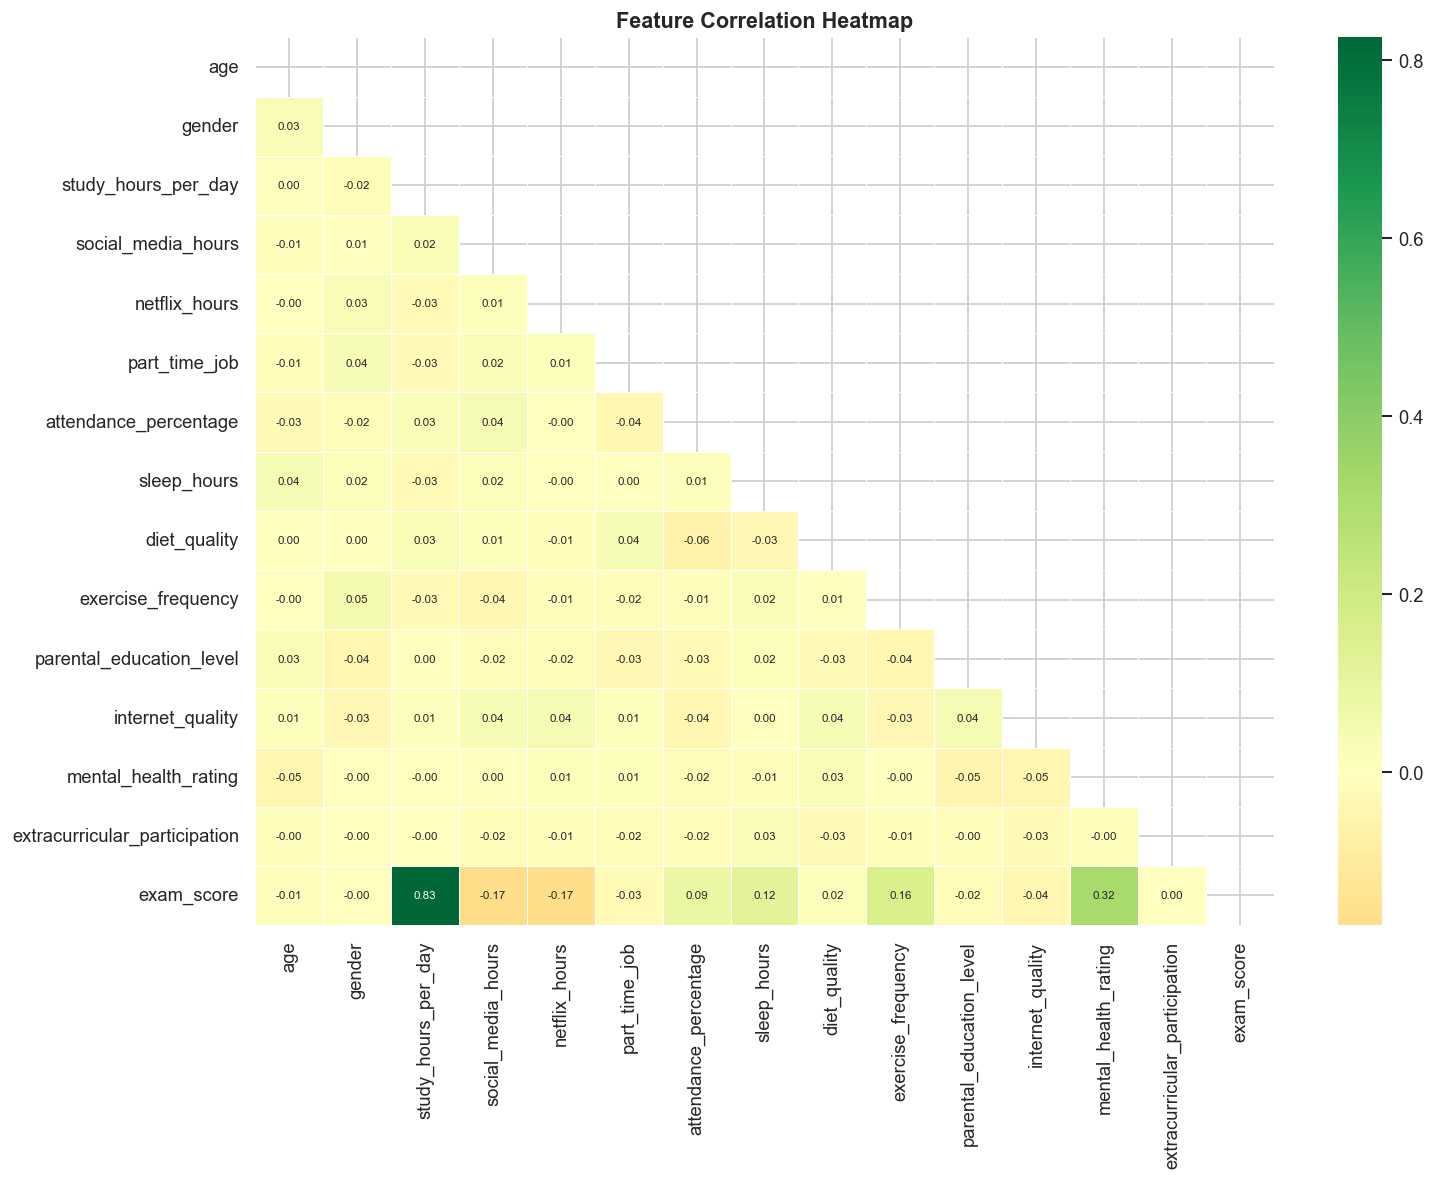

In [9]:
fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(df_enc.corr(), dtype=bool))
sns.heatmap(df_enc.corr(), mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            annot_kws={'size': 7}, ax=ax)
ax.set_title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 1.6 Exam Score vs Key Features (Box Plots)

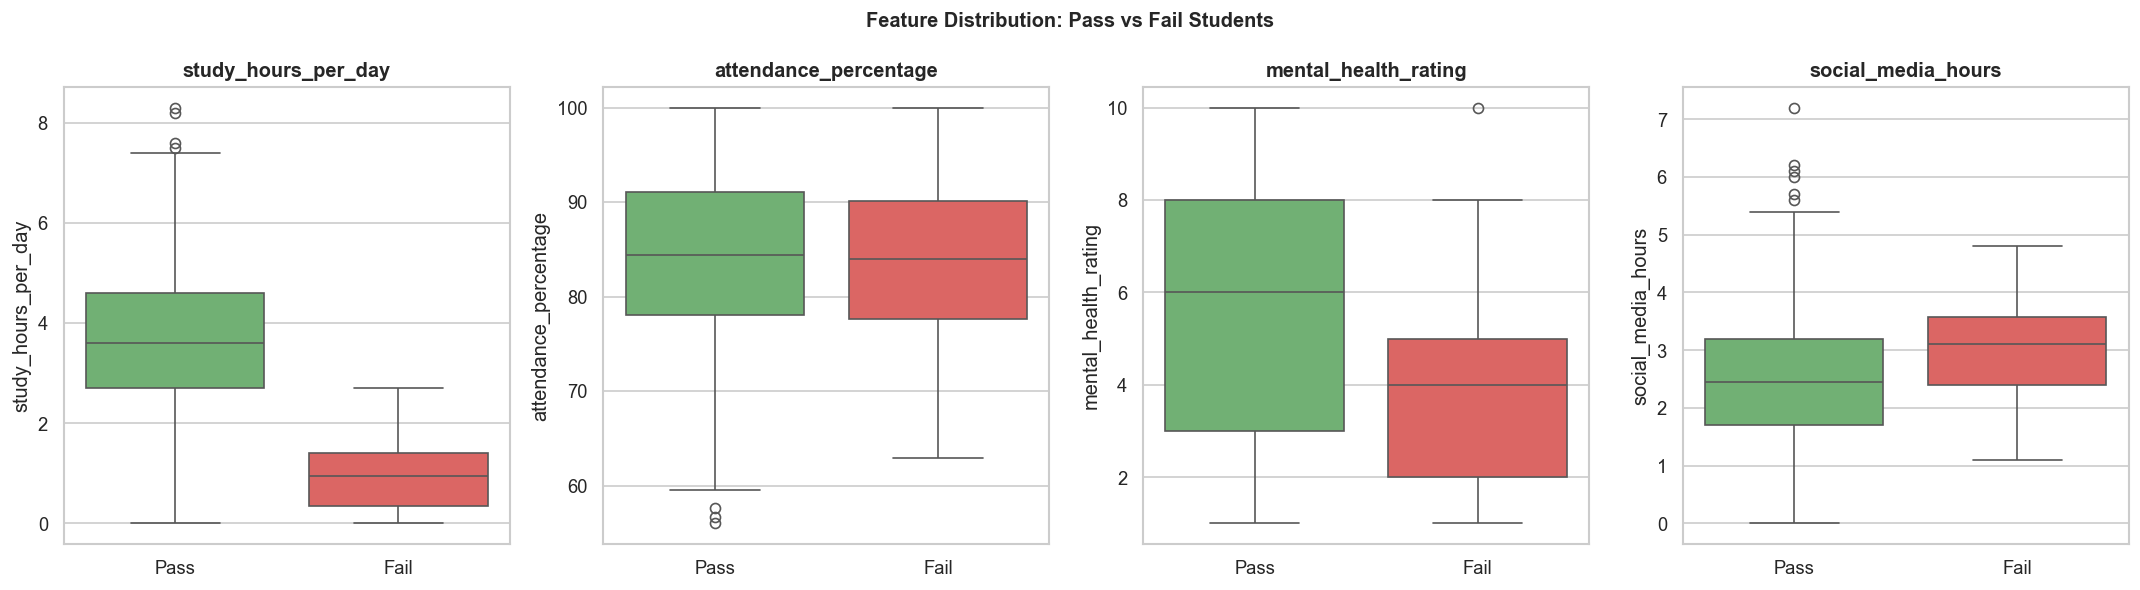

In [10]:
df_tmp = df_raw.copy()
df_tmp['pass_fail'] = df_tmp['exam_score'].apply(lambda x: 'Pass' if x >= 40 else 'Fail')

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
key_features = ['study_hours_per_day','attendance_percentage',
                 'mental_health_rating','social_media_hours']

for i, feat in enumerate(key_features):
    sns.boxplot(data=df_tmp, x='pass_fail', y=feat,
                palette={'Fail':'#ef5350','Pass':'#66bb6a'}, ax=axes[i])
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Feature Distribution: Pass vs Fail Students', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🔧 Section 2 — Data Preprocessing

Steps applied:
1. **Drop `student_id`** — unique identifier, no predictive power
2. **Fill missing values** — `parental_education_level` (91 NaN → mode imputation)
3. **Winsorise outliers** — cap extreme values at 1.5 × IQR to reduce noise
4. **Ordinal encode** — meaningful ordering for categorical features (Poor→0, Fair→1, Good→2)

In [11]:
df = df_raw.copy()

# ── Step 1: Drop student_id ──────────────────────────────────────
df.drop(columns=['student_id'], inplace=True)
print('✅ Dropped student_id. Shape:', df.shape)

✅ Dropped student_id. Shape: (1000, 15)


In [12]:
# ── Step 2: Fill missing values ─────────────────────────────────
print('Missing before:', df.isnull().sum().sum())

mode_edu = df['parental_education_level'].mode()[0]
df['parental_education_level'] = df['parental_education_level'].fillna(mode_edu)

print(f'Filled parental_education_level NaNs with mode: "{mode_edu}"')
print('Missing after: ', df.isnull().sum().sum())

Missing before: 91
Filled parental_education_level NaNs with mode: "High School"
Missing after:  0


In [13]:
# ── Step 3: Winsorise outliers (1.5 × IQR) ──────────────────────
WINSORISE_COLS = ['study_hours_per_day','social_media_hours','netflix_hours',
                  'attendance_percentage','sleep_hours']
winsorise_bounds = {}
print(f"{'Column':<32} {'Outliers':>8}  {'Lower':>8}  {'Upper':>8}")
print('-' * 62)
for col in WINSORISE_COLS:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR    = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out  = int(((df[col] < lo) | (df[col] > hi)).sum())
    df[col] = df[col].clip(lo, hi)
    winsorise_bounds[col] = (lo, hi)
    print(f'{col:<32} {n_out:>8}  {lo:>8.2f}  {hi:>8.2f}')
print('\n✅ Outliers capped.')

Column                           Outliers     Lower     Upper
--------------------------------------------------------------
study_hours_per_day                     7     -0.25      7.35
social_media_hours                      5     -0.70      5.70
netflix_hours                           4     -1.29      4.81
attendance_percentage                   3     58.46    110.56
sleep_hours                             2      3.05      9.85

✅ Outliers capped.


In [14]:
# ── Step 4: Ordinal encoding ─────────────────────────────────────
ORDINAL_MAPS = {
    'diet_quality':                  {'Poor':0,'Fair':1,'Good':2},
    'internet_quality':              {'Poor':0,'Average':1,'Good':2},
    'parental_education_level':      {'High School':0,'Bachelor':1,'Master':2},
    'part_time_job':                 {'No':0,'Yes':1},
    'extracurricular_participation': {'No':0,'Yes':1},
    'gender':                        {'Female':0,'Male':1,'Other':2},
}

for col, mapping in ORDINAL_MAPS.items():
    df[col] = df[col].map(mapping)
    print(f'  Encoded {col}: {mapping}')

print(f'\n✅ Encoding done. Remaining nulls: {df.isnull().sum().sum()}')
df.head(3)

  Encoded diet_quality: {'Poor': 0, 'Fair': 1, 'Good': 2}
  Encoded internet_quality: {'Poor': 0, 'Average': 1, 'Good': 2}
  Encoded parental_education_level: {'High School': 0, 'Bachelor': 1, 'Master': 2}
  Encoded part_time_job: {'No': 0, 'Yes': 1}
  Encoded extracurricular_participation: {'No': 0, 'Yes': 1}
  Encoded gender: {'Female': 0, 'Male': 1, 'Other': 2}

✅ Encoding done. Remaining nulls: 0


,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,23,0,0.0,1.2,1.1,0,85.0,8.0,1,6,2,1,8,1,56.2
1,20,0,6.9,2.8,2.3,0,97.3,4.6,2,6,0,1,8,0,100.0
2,21,1,1.4,3.1,1.3,0,94.8,8.0,0,1,0,0,1,0,34.3


---
## ⚖️  Section 3 — Fairness Audit (Demographic Parity)

**Demographic Parity** requires that the predicted positive rate (Pass) is equal across all demographic groups.

We audit two protected attributes:
- **Gender** (Female / Male / Other)
- **Parental Education Level** (High School / Bachelor / Master)

A **Disparate Impact Ratio** close to 1.0 indicates fairness. Values below 0.80 signal potential bias (the 80% rule).

In [15]:
# Use raw df_raw for readable labels
df_audit = df_raw.copy()
df_audit['pass_fail'] = (df_audit['exam_score'] >= 40).astype(int)

def fairness_audit(df, protected_col, target='pass_fail'):
    groups = df.groupby(protected_col)[target].agg(['mean','count'])
    groups.columns = ['Pass Rate', 'Count']
    groups['Pass Rate %'] = (groups['Pass Rate'] * 100).round(1)
    max_rate = groups['Pass Rate'].max()
    groups['Disparate Impact'] = (groups['Pass Rate'] / max_rate).round(3)
    groups['Fair (≥0.80)?'] = groups['Disparate Impact'].apply(
        lambda x: '✅ Yes' if x >= 0.80 else '❌ No'
    )
    return groups

print('=== Fairness Audit: Gender ===')
gender_audit = fairness_audit(df_audit, 'gender')
display(gender_audit)

print('\n=== Fairness Audit: Parental Education ===')
edu_audit = fairness_audit(df_audit, 'parental_education_level')
display(edu_audit)

=== Fairness Audit: Gender ===


,Pass Rate,Count,Pass Rate %,Disparate Impact,Fair (≥0.80)?
gender,,,,,
Female,0.962578,481,96.3,0.963,✅ Yes
Male,0.949686,477,95.0,0.950,✅ Yes
Other,1.000000,42,100.0,1.000,✅ Yes



=== Fairness Audit: Parental Education ===


,Pass Rate,Count,Pass Rate %,Disparate Impact,Fair (≥0.80)?
parental_education_level,,,,,
Bachelor,0.948571,350,94.9,0.978,✅ Yes
High School,0.964286,392,96.4,0.994,✅ Yes
Master,0.970060,167,97.0,1.000,✅ Yes


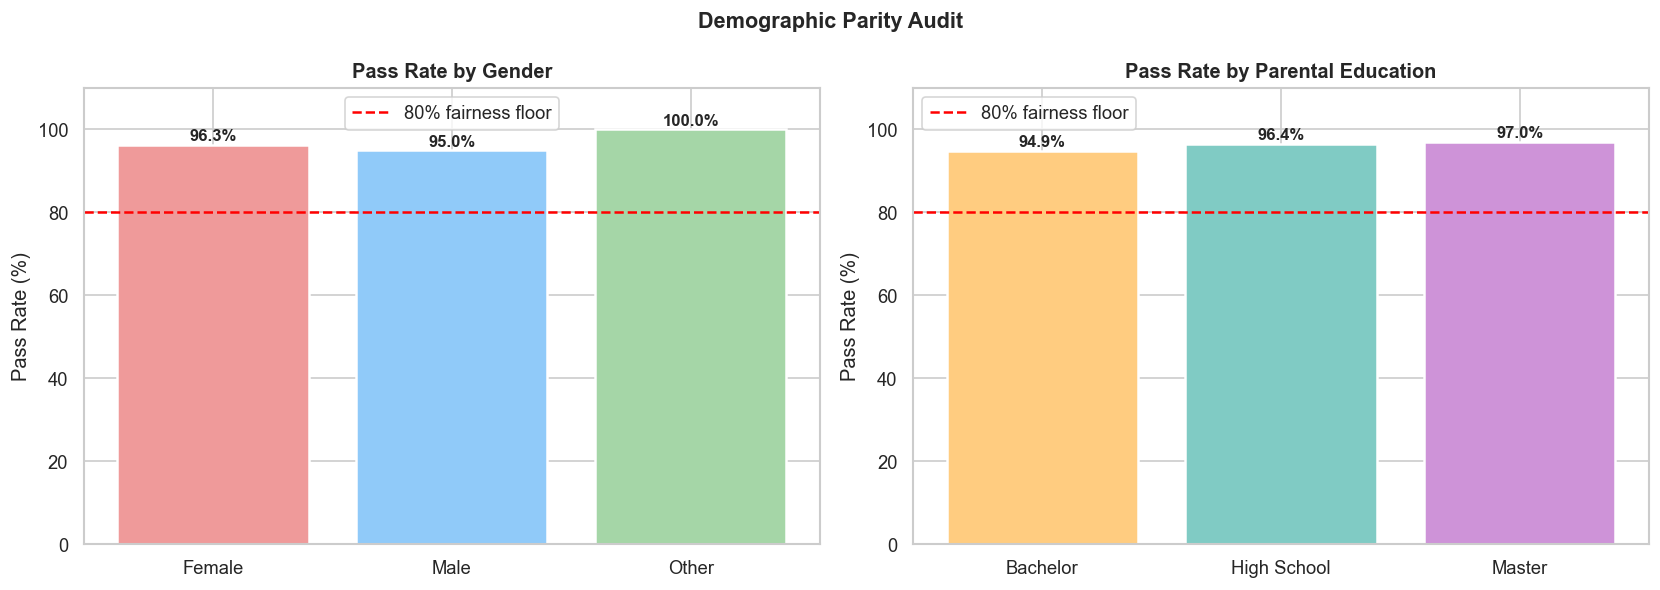


📌 Note: Disparate Impact Ratio < 0.80 indicates potential bias requiring mitigation.


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gender pass rates
g_rates = df_audit.groupby('gender')['pass_fail'].mean() * 100
bars1 = axes[0].bar(g_rates.index, g_rates.values,
                    color=['#ef9a9a','#90caf9','#a5d6a7'], edgecolor='white', linewidth=1.5)
axes[0].axhline(80, color='red', linestyle='--', linewidth=1.5, label='80% fairness floor')
axes[0].set_ylim(0, 110)
axes[0].set_title('Pass Rate by Gender', fontweight='bold')
axes[0].set_ylabel('Pass Rate (%)')
axes[0].legend()
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=10, fontweight='bold')

# Parental education pass rates
p_rates = df_audit.groupby('parental_education_level')['pass_fail'].mean() * 100
bars2 = axes[1].bar(p_rates.index, p_rates.values,
                    color=['#ffcc80','#80cbc4','#ce93d8'], edgecolor='white', linewidth=1.5)
axes[1].axhline(80, color='red', linestyle='--', linewidth=1.5, label='80% fairness floor')
axes[1].set_ylim(0, 110)
axes[1].set_title('Pass Rate by Parental Education', fontweight='bold')
axes[1].set_ylabel('Pass Rate (%)')
axes[1].legend()
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Demographic Parity Audit', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n📌 Note: Disparate Impact Ratio < 0.80 indicates potential bias requiring mitigation.')

---
## ⚙️  Section 4 — Feature Engineering

We create 5 compound features that combine raw variables into more expressive signals:

| Feature | Formula | Rationale |
|---|---|---|
| `study_x_attendance` | `study_hours × attendance / 100` | Joint engagement — strongest compound predictor |
| `distraction_hours` | `social_media + netflix` | Total time lost to digital distractions |
| `wellbeing_index` | `0.4×sleep + 0.4×mental + 0.2×diet` | Composite wellbeing score |
| `productive_ratio` | `study / (distraction + 1)` | Productive vs distracted time ratio |
| `at_risk_flag` | `1 if attendance<60 OR study<1.5` | Binary early-warning flag |

In [17]:
# study × attendance: captures JOINT disengagement (0×anything = 0)
df['study_x_attendance'] = df['study_hours_per_day'] * df['attendance_percentage'] / 100.0

# Total digital distraction hours
df['distraction_hours'] = df['social_media_hours'] + df['netflix_hours']

# Composite wellbeing index
df['wellbeing_index'] = (
    df['sleep_hours'] / 8.0 * 0.4 +
    df['mental_health_rating'] / 10.0 * 0.4 +
    df['diet_quality'] / 2.0 * 0.2
)

# Study productivity ratio vs distractions
df['productive_ratio'] = df['study_hours_per_day'] / (df['distraction_hours'] + 1)

# Binary at-risk flag
df['at_risk_flag'] = (
    (df['attendance_percentage'] < 60) | (df['study_hours_per_day'] < 1.5)
).astype(int)

print('✅ Engineered features added:')
new_feats = ['study_x_attendance','distraction_hours','wellbeing_index',
             'productive_ratio','at_risk_flag']
print(df[new_feats].describe().round(3))

✅ Engineered features added:
       study_x_attendance  distraction_hours  wellbeing_index  \
count            1000.000           1000.000         1000.000   
mean                2.989              4.321            0.660   
std                 1.304              1.589            0.148   
min                 0.000              0.200            0.265   
25%                 2.097              3.300            0.550   
50%                 2.956              4.400            0.655   
75%                 3.831              5.400            0.770   
max                 7.306              9.200            1.045   

       productive_ratio  at_risk_flag  
count          1000.000      1000.000  
mean              0.747         0.087  
std               0.446         0.282  
min               0.000         0.000  
25%               0.472         0.000  
50%               0.660         0.000  
75%               0.936         0.000  
max               4.500         1.000  


In [18]:
# ── Create target variable ──────────────────────────────────────
df['pass_fail'] = (df['exam_score'] >= 40).astype(int)  # 1=Pass, 0=Fail

# Drop exam_score — it IS the target; keeping it would be data leakage!
df.drop(columns=['exam_score'], inplace=True)

TARGET   = 'pass_fail'
FEATURES = [c for c in df.columns if c != TARGET]

print(f'Target: pass_fail | Fail={int((df[TARGET]==0).sum())} | Pass={int((df[TARGET]==1).sum())}')
print(f'\nFinal feature set ({len(FEATURES)}):')
for i, f in enumerate(FEATURES, 1):
    print(f'  {i:2d}. {f}')
print(f'\nFinal shape: {df.shape}')

Target: pass_fail | Fail=42 | Pass=958

Final feature set (19):
   1. age
   2. gender
   3. study_hours_per_day
   4. social_media_hours
   5. netflix_hours
   6. part_time_job
   7. attendance_percentage
   8. sleep_hours
   9. diet_quality
  10. exercise_frequency
  11. parental_education_level
  12. internet_quality
  13. mental_health_rating
  14. extracurricular_participation
  15. study_x_attendance
  16. distraction_hours
  17. wellbeing_index
  18. productive_ratio
  19. at_risk_flag

Final shape: (1000, 20)


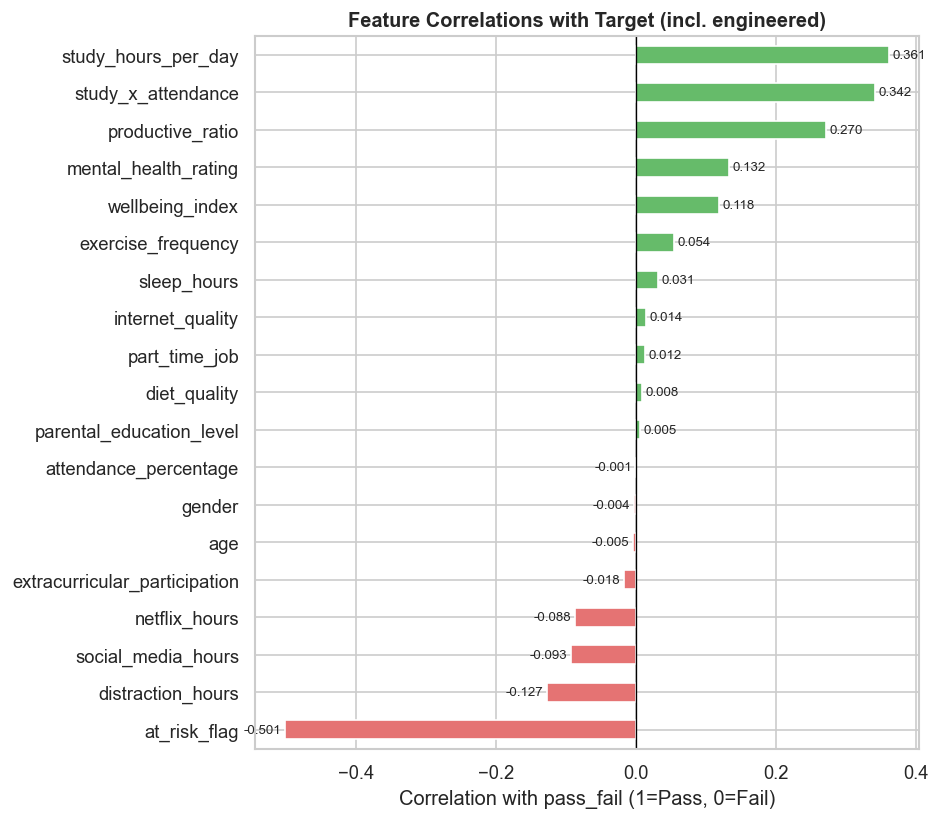

In [19]:
# Correlation of all features (including engineered) with pass_fail
corr2 = df.corr()['pass_fail'].drop('pass_fail').sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
colors = ['#e57373' if v < 0 else '#66bb6a' for v in corr2]
corr2.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlation with pass_fail (1=Pass, 0=Fail)')
ax.set_title('Feature Correlations with Target (incl. engineered)', fontweight='bold')
for i, (val, name) in enumerate(zip(corr2, corr2.index)):
    ax.text(val + (0.005 if val>=0 else -0.005), i, f'{val:.3f}',
            va='center', ha='left' if val>=0 else 'right', fontsize=8)
plt.tight_layout()
plt.show()

---
## ⚖️  Section 5 — Handling Class Imbalance

The dataset has a **1:22 imbalance** (42 Fail vs 958 Pass).  
A naive classifier can reach 95.8% accuracy by always predicting Pass — completely useless for early intervention.

**Strategy used:**
1. **Bootstrap oversampling** — replicate Fail examples to match Pass count in training data  
2. **`class_weight='balanced'`** inside Random Forest as a second layer  
3. **Decision threshold tuning** — lower the default 0.5 to increase Fail recall

In [20]:
X = df[FEATURES]
y = df[TARGET]

# ── Stratified train/test split ──────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {len(X_train)} | Test: {len(X_test)}')
print(f'Train — Fail: {int((y_train==0).sum())} | Pass: {int((y_train==1).sum())}')
print(f'Test  — Fail: {int((y_test==0).sum())}  | Pass: {int((y_test==1).sum())}')

Train: 800 | Test: 200
Train — Fail: 34 | Pass: 766
Test  — Fail: 8  | Pass: 192


Train (original) - Fail: 34 | Pass: 766
Train (balanced) - Fail: 766 | Pass: 766

This balanced set is used ONLY for final model refit.
GridSearchCV below uses ImbPipeline: oversampling inside each fold.


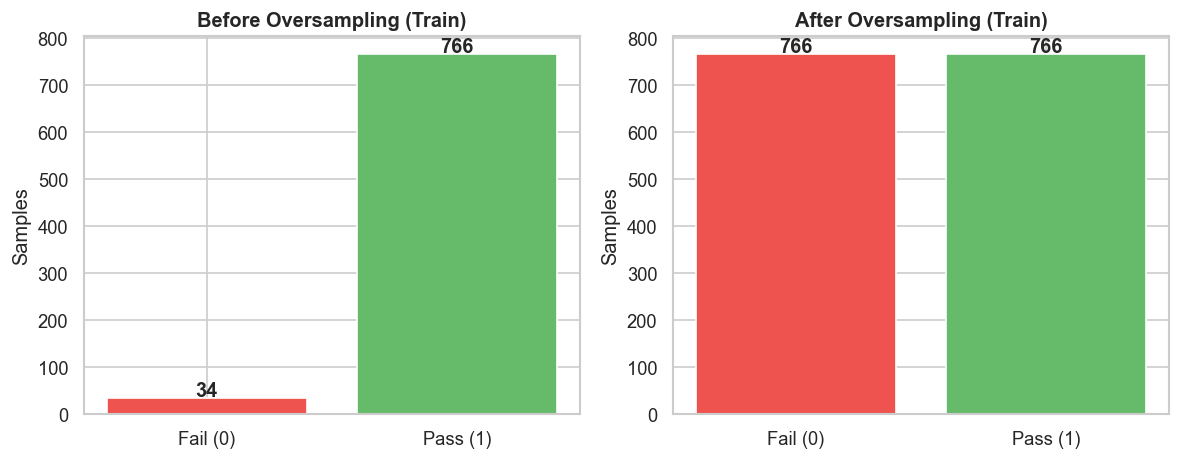

In [21]:
# ── Oversampling strategy ─────────────────────────────────────
# IMPORTANT: To prevent data leakage, oversampling is applied
# INSIDE each CV fold via imblearn.pipeline.Pipeline, NOT before CV.
#
# This cell prepares a balanced training set for the FINAL model
# fit only (after hyperparameters are selected). GridSearchCV in
# the next cells uses ImbPipeline to resample within each fold.

train_df  = pd.concat([X_train, y_train], axis=1)
fail_rows = train_df[train_df[TARGET] == 0]
pass_rows = train_df[train_df[TARGET] == 1]

fail_up = resample(fail_rows, replace=True,
                   n_samples=len(pass_rows),
                   random_state=RANDOM_STATE)

balanced_train = pd.concat([pass_rows, fail_up]).sample(frac=1, random_state=RANDOM_STATE)

X_train_bal = balanced_train[FEATURES]
y_train_bal = balanced_train[TARGET]

print(f'Train (original) - Fail: {int((y_train==0).sum())} | Pass: {int((y_train==1).sum())}')
print(f'Train (balanced) - Fail: {int((y_train_bal==0).sum())} | Pass: {int((y_train_bal==1).sum())}')
print(f'\nThis balanced set is used ONLY for final model refit.')
print(f'GridSearchCV below uses ImbPipeline: oversampling inside each fold.')

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (counts, title) in zip(axes, [
    ([int((y_train==0).sum()), int((y_train==1).sum())], 'Before Oversampling (Train)'),
    ([int((y_train_bal==0).sum()), int((y_train_bal==1).sum())], 'After Oversampling (Train)')
]):
    ax.bar(['Fail (0)','Pass (1)'], counts, color=['#ef5350','#66bb6a'], edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Samples')
    for i, v in enumerate(counts):
        ax.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🤖 Section 6 — Model Training (Leak-Free CV)

We train two ensemble classifiers and select the best via ROC-AUC:
- **Random Forest** — robust, interpretable, excellent with class weights
- **XGBoost / GradientBoosting** — often superior on tabular data, handles imbalance via `scale_pos_weight`

Both are tuned with **5-fold Stratified GridSearchCV** using `ImbPipeline` from **imblearn**.
This ensures oversampling is applied **inside** each CV fold (train portion only),
preventing data leakage from synthetic minority samples leaking into validation folds.

In [22]:
# ── Model 1: Random Forest (ImbPipeline - leak-free CV) ──────
print('Training Random Forest with ImbPipeline...')
print('Oversampling happens INSIDE each CV fold to prevent leakage.\n')

rf_param_grid = {
    'model__n_estimators':     [100, 200, 300],
    'model__max_depth':        [5, 10, 15, None],
    'model__min_samples_leaf': [1, 3, 5],
    'model__max_features':     ['sqrt', 'log2'],
}

rf_pipe = ImbPipeline([
    ('sampler', RandomOverSampler(random_state=RANDOM_STATE)),
    ('model',   RandomForestClassifier(class_weight='balanced',
                                        random_state=RANDOM_STATE, n_jobs=-1)),
])

rf_grid = GridSearchCV(
    rf_pipe,
    param_grid=rf_param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
)
# Fit on ORIGINAL imbalanced training data - ImbPipeline handles resampling per fold
rf_grid.fit(X_train, y_train)

print(f'\nBest params : {rf_grid.best_params_}')
print(f'Best CV F1  : {rf_grid.best_score_:.4f}')

rf_best = rf_grid.best_estimator_.named_steps['model']
rf_proba = rf_grid.best_estimator_.predict_proba(X_test)
rf_auc = roc_auc_score(y_test, rf_proba[:, 1])
rf_pred = rf_grid.best_estimator_.predict(X_test)
print(f'Test ROC-AUC: {rf_auc:.4f}')
print(f'\nClassification Report (RF):')
print(classification_report(y_test, rf_pred, target_names=['Fail','Pass']))

Training Random Forest with ImbPipeline...
Oversampling happens INSIDE each CV fold to prevent leakage.

Fitting 5 folds for each of 72 candidates, totalling 360 fits

Best params : {'model__max_depth': 15, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 5, 'model__n_estimators': 200}
Best CV F1  : 0.7866
Test ROC-AUC: 0.9733

Classification Report (RF):
              precision    recall  f1-score   support

        Fail       0.71      0.62      0.67         8
        Pass       0.98      0.99      0.99       192

    accuracy                           0.97       200
   macro avg       0.85      0.81      0.83       200
weighted avg       0.97      0.97      0.97       200



In [23]:
# ── Model 2: XGBoost / GradientBoosting (ImbPipeline - leak-free CV)
imbalance_ratio = int((y_train==1).sum() / max((y_train==0).sum(), 1))
model_name = "XGBoost" if HAS_XGB else "GradientBoosting"
print(f'Training {model_name} with ImbPipeline...')
print(f'Imbalance ratio for scale_pos_weight: {imbalance_ratio}')
print(f'Oversampling happens INSIDE each CV fold to prevent leakage.\n')

if HAS_XGB:
    xgb_param_grid = {
        'model__n_estimators':     [100, 200, 300],
        'model__max_depth':        [3, 5, 7],
        'model__learning_rate':    [0.01, 0.05, 0.1],
        'model__subsample':        [0.8, 1.0],
        'model__scale_pos_weight': [1, imbalance_ratio//2, imbalance_ratio],
    }
    xgb_base = XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        use_label_encoder=False,
        n_jobs=-1,
    )
else:
    xgb_param_grid = {
        'model__n_estimators':  [100, 200],
        'model__max_depth':     [3, 5],
        'model__learning_rate': [0.05, 0.1],
        'model__subsample':     [0.8, 1.0],
    }
    xgb_base = XGBClassifier(random_state=RANDOM_STATE)

xgb_pipe = ImbPipeline([
    ('sampler', RandomOverSampler(random_state=RANDOM_STATE)),
    ('model',   xgb_base),
])

xgb_grid = GridSearchCV(
    xgb_pipe,
    param_grid=xgb_param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
)
# Fit on ORIGINAL imbalanced training data
xgb_grid.fit(X_train, y_train)

print(f'\nBest params : {xgb_grid.best_params_}')
print(f'Best CV F1  : {xgb_grid.best_score_:.4f}')

xgb_best = xgb_grid.best_estimator_.named_steps['model']
xgb_proba = xgb_grid.best_estimator_.predict_proba(X_test)
xgb_auc = roc_auc_score(y_test, xgb_proba[:, 1])
xgb_pred = xgb_grid.best_estimator_.predict(X_test)
print(f'Test ROC-AUC: {xgb_auc:.4f}')
print(f'\nClassification Report (XGB):')
print(classification_report(y_test, xgb_pred, target_names=['Fail','Pass']))

Training XGBoost with ImbPipeline...
Imbalance ratio for scale_pos_weight: 22
Oversampling happens INSIDE each CV fold to prevent leakage.

Fitting 5 folds for each of 162 candidates, totalling 810 fits

Best params : {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200, 'model__scale_pos_weight': 1, 'model__subsample': 0.8}
Best CV F1  : 0.8239
Test ROC-AUC: 0.9486

Classification Report (XGB):
              precision    recall  f1-score   support

        Fail       0.83      0.62      0.71         8
        Pass       0.98      0.99      0.99       192

    accuracy                           0.98       200
   macro avg       0.91      0.81      0.85       200
weighted avg       0.98      0.98      0.98       200



In [24]:
# ── Model Comparison ────────────────────────────────────────────
results = pd.DataFrame({
    'Model':    ['Random Forest', 'XGBoost/GB'],
    'ROC-AUC':  [rf_auc, xgb_auc],
    'F1-Macro': [f1_score(y_test, rf_pred, average='macro'),
                 f1_score(y_test, xgb_pred, average='macro')],
    'Fail-Recall':[recall_score(y_test, rf_pred, pos_label=0),
                   recall_score(y_test, xgb_pred, pos_label=0)],
    'Fail-Prec':  [precision_score(y_test, rf_pred, pos_label=0, zero_division=0),
                   precision_score(y_test, xgb_pred, pos_label=0, zero_division=0)],
}).round(4)

print('=== Model Comparison ===')
display(results)

if rf_auc >= xgb_auc:
    winner = rf_best
    winner_name = 'RandomForestClassifier'
    winner_proba_test = rf_proba
    print(f'\n✅ Selected: Random Forest (AUC {rf_auc:.4f})')
else:
    winner = xgb_best
    winner_name = 'XGBoost'
    winner_proba_test = xgb_proba
    print(f'\n✅ Selected: XGBoost (AUC {xgb_auc:.4f})')

=== Model Comparison ===


,Model,ROC-AUC,F1-Macro,Fail-Recall,Fail-Prec
0,Random Forest,0.9733,0.8268,0.625,0.7143
1,XGBoost/GB,0.9486,0.8520,0.625,0.8333



✅ Selected: Random Forest (AUC 0.9733)


---
## 🎯 Section 7 — Decision Threshold Tuning

The default threshold of **0.5** is optimised for balanced classes.  
With 4.2% Fail rate, we need a **lower threshold** to catch more failing students (higher recall).

We sweep thresholds and pick the one maximising **F1-score for the Fail class**.

In [25]:
fail_probs = winner_proba_test[:, 0]   # probability of being FAIL (class 0)

thresholds  = np.arange(0.05, 0.75, 0.05)
f1_fails    = []
prec_fails  = []
rec_fails   = []

print(f"{'Threshold':>12}  {'Precision':>10}  {'Recall':>8}  {'F1-Fail':>8}")
print('-' * 48)

best_threshold, best_f1 = 0.5, 0.0

for t in thresholds:
    preds     = (fail_probs >= t).astype(int)       # 1 = predicted FAIL
    true_fail = (y_test == 0).astype(int)           # 1 = actually FAIL
    prec = precision_score(true_fail, preds, zero_division=0)
    rec  = recall_score(true_fail, preds, zero_division=0)
    f1f  = f1_score(true_fail, preds, zero_division=0)
    f1_fails.append(f1f)
    prec_fails.append(prec)
    rec_fails.append(rec)
    marker = ' ← best' if f1f > best_f1 else ''
    print(f"{t:>12.2f}  {prec:>10.3f}  {rec:>8.3f}  {f1f:>8.3f}{marker}")
    if f1f > best_f1:
        best_f1, best_threshold = f1f, t

print(f"\n✅ Optimal threshold: {best_threshold:.2f}  (Fail F1 = {best_f1:.3f})")

   Threshold   Precision    Recall   F1-Fail
------------------------------------------------
        0.05       0.151     1.000     0.262 ← best
        0.10       0.205     1.000     0.340 ← best
        0.15       0.259     0.875     0.400 ← best
        0.20       0.333     0.875     0.483 ← best
        0.25       0.353     0.750     0.480
        0.30       0.375     0.750     0.500 ← best
        0.35       0.385     0.625     0.476
        0.40       0.556     0.625     0.588 ← best
        0.45       0.625     0.625     0.625 ← best
        0.50       0.714     0.625     0.667 ← best
        0.55       0.714     0.625     0.667
        0.60       0.833     0.625     0.714 ← best
        0.65       0.833     0.625     0.714
        0.70       0.833     0.625     0.714

✅ Optimal threshold: 0.60  (Fail F1 = 0.714)


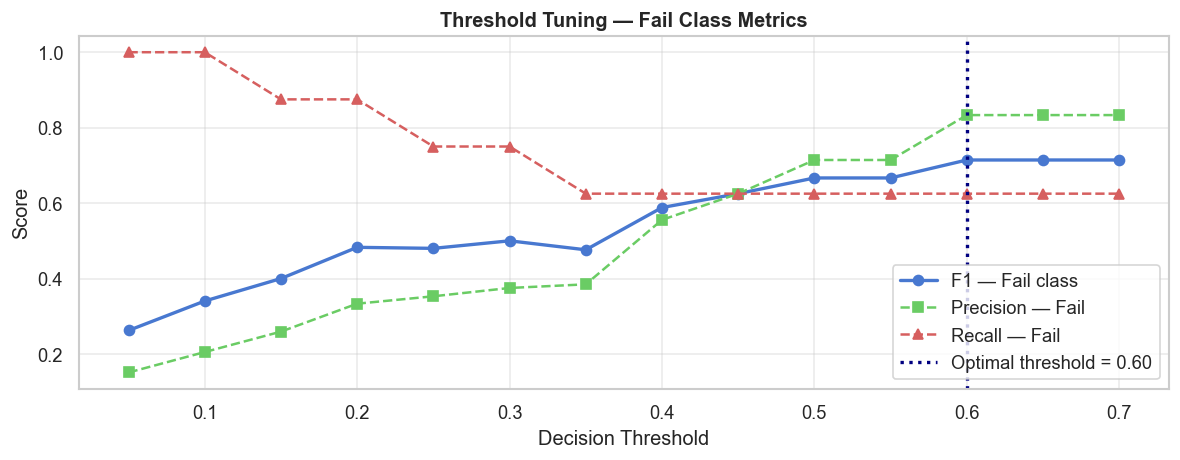

In [26]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds, f1_fails,   'b-o',  label='F1 — Fail class',  linewidth=2)
ax.plot(thresholds, prec_fails,  'g--s', label='Precision — Fail', linewidth=1.5)
ax.plot(thresholds, rec_fails,   'r--^', label='Recall — Fail',    linewidth=1.5)
ax.axvline(best_threshold, color='navy', linestyle=':', linewidth=2,
           label=f'Optimal threshold = {best_threshold:.2f}')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('Threshold Tuning — Fail Class Metrics', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

---
## 📊 Section 8 — Final Model Evaluation

Evaluation at the tuned threshold using the held-out test set.

In [27]:
# Apply tuned threshold
final_preds = np.where(fail_probs >= best_threshold, 0, 1)   # 0=Fail, 1=Pass

print(f'=== Final Evaluation at threshold = {best_threshold:.2f} ===')
print(classification_report(y_test, final_preds, target_names=['Fail','Pass']))

print(f'ROC-AUC: {roc_auc_score(y_test, winner_proba_test[:, 1]):.4f}')

=== Final Evaluation at threshold = 0.60 ===
              precision    recall  f1-score   support

        Fail       0.83      0.62      0.71         8
        Pass       0.98      0.99      0.99       192

    accuracy                           0.98       200
   macro avg       0.91      0.81      0.85       200
weighted avg       0.98      0.98      0.98       200

ROC-AUC: 0.9733


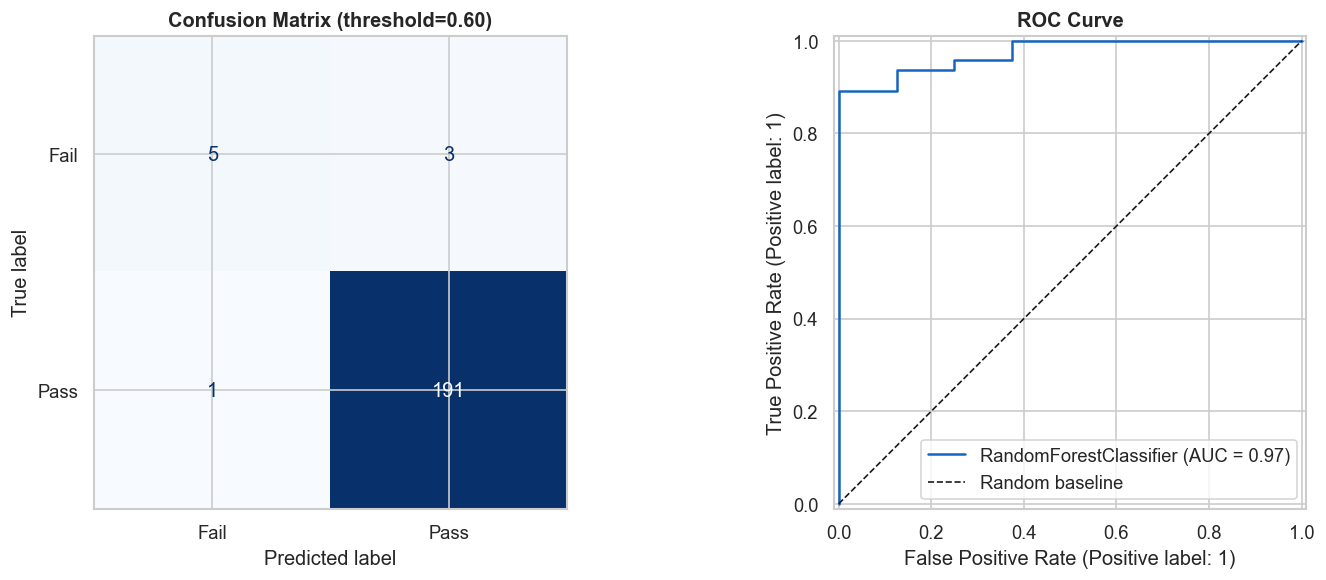

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
cm = confusion_matrix(y_test, final_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fail','Pass'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Confusion Matrix (threshold={best_threshold:.2f})', fontweight='bold')

# ROC curve
RocCurveDisplay.from_predictions(y_test, winner_proba_test[:, 1],
                                  name=winner_name, ax=axes[1], color='#1565c0')
axes[1].plot([0,1],[0,1],'k--',linewidth=1, label='Random baseline')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

In [29]:
# ── 5-fold Cross-validation (LEAK-FREE - oversampling inside folds) ──
# Uses ImbPipeline so oversampling only touches training portion of each fold.
# This produces honest, unbiased CV scores.

cv_pipe = ImbPipeline([
    ('sampler', RandomOverSampler(random_state=RANDOM_STATE)),
    ('model',   winner),
])

cv_scores = cross_val_score(
    cv_pipe, X, y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc'
)
print(f'5-Fold CV ROC-AUC (leak-free): {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')
print(f'Individual folds : {[round(s,4) for s in cv_scores]}')
print(f'\nPrevious CV used pre-oversampled data which inflated scores.')
print(f'This version applies RandomOverSampler inside each fold via ImbPipeline.')

5-Fold CV ROC-AUC (leak-free): 0.9665 +/- 0.0191
Individual folds : [np.float64(0.9336), np.float64(0.9622), np.float64(0.9701), np.float64(0.975), np.float64(0.9919)]

Previous CV used pre-oversampled data which inflated scores.
This version applies RandomOverSampler inside each fold via ImbPipeline.


---
## 📊 Section 8b — Bootstrap Confidence Intervals (Evaluation Reliability)

With only ~8 Fail cases in the test set, point-estimate metrics are unreliable.
A single misclassification can swing F1 by 12.5 percentage points.

We use **1,000 stratified bootstrap resamples** of the test set to compute
**95% confidence intervals** for Precision, Recall, F1 (Fail class), and ROC-AUC.
This directly addresses the evaluation fragility concern.

=== Bootstrap Evaluation (1000 resamples, threshold=0.60) ===
  Valid resamples: 1000 / 1000

  Fail Precision      : median=0.833  95% CI [0.374, 1.000]
  Fail Recall         : median=0.636  95% CI [0.250, 1.000]
  Fail F1             : median=0.727  95% CI [0.307, 0.933]
  ROC-AUC             : median=0.976  95% CI [0.936, 1.000]


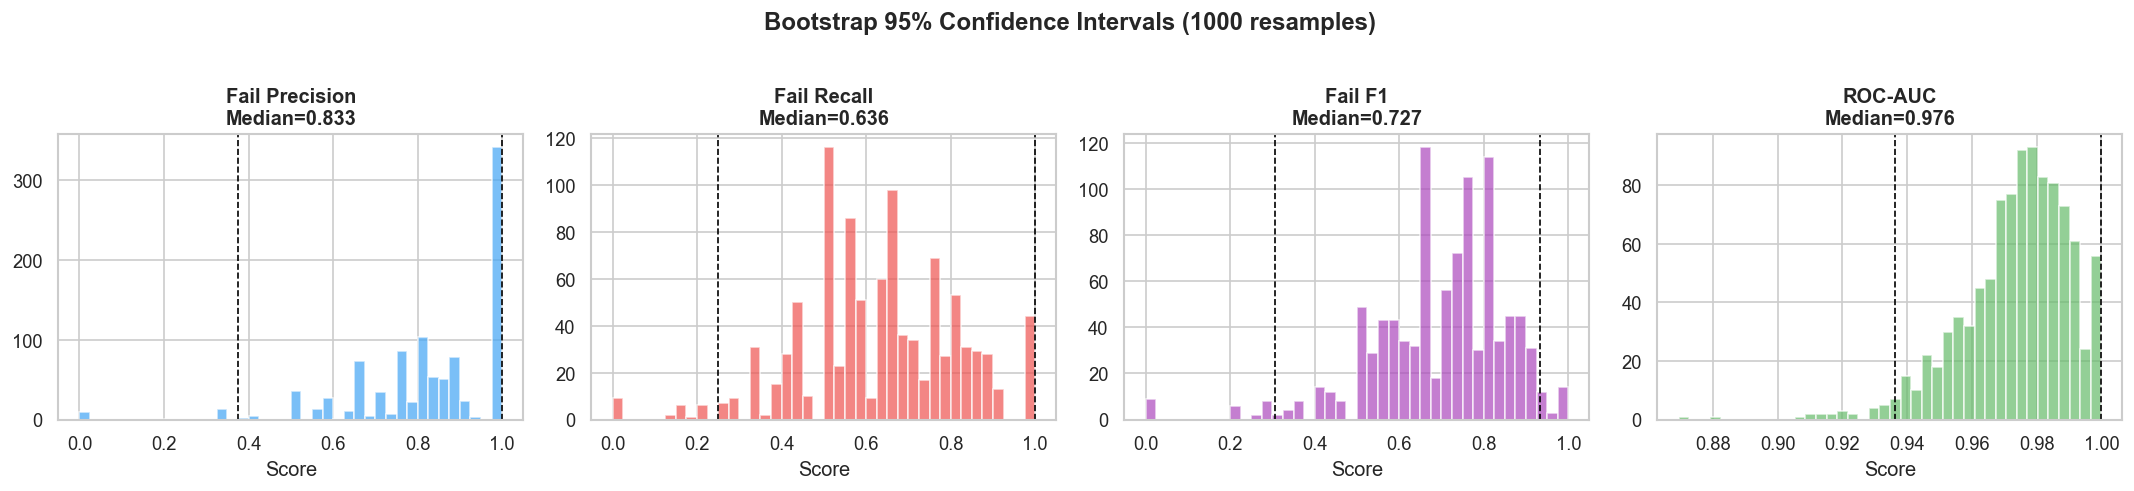


  Wide CIs reflect the small Fail-class support in the test set.
  These intervals are reported alongside point estimates for transparency.


In [30]:
# ── Bootstrap Confidence Intervals (1000 resamples) ──────────
from sklearn.utils import resample as sk_resample

n_bootstraps = 1000
rng = np.random.RandomState(RANDOM_STATE)

boot_precision = []
boot_recall    = []
boot_f1        = []
boot_auc       = []

fail_probs_test = winner.predict_proba(X_test)[:, 0]

for i in range(n_bootstraps):
    indices = rng.choice(len(y_test), size=len(y_test), replace=True)
    
    y_boot   = y_test.values[indices]
    prob_boot = fail_probs_test[indices]
    
    # Skip if bootstrap sample has no Fail cases
    if len(np.unique(y_boot)) < 2:
        continue
    
    preds_boot  = np.where(prob_boot >= best_threshold, 0, 1)
    true_fail   = (y_boot == 0).astype(int)
    pred_fail   = (preds_boot == 0).astype(int)
    
    p = precision_score(true_fail, pred_fail, zero_division=0)
    r = recall_score(true_fail, pred_fail, zero_division=0)
    f = f1_score(true_fail, pred_fail, zero_division=0)
    a = roc_auc_score(y_boot, winner.predict_proba(X_test.iloc[indices])[:, 1])
    
    boot_precision.append(p)
    boot_recall.append(r)
    boot_f1.append(f)
    boot_auc.append(a)

def ci(arr, label):
    lo, hi = np.percentile(arr, [2.5, 97.5])
    med = np.median(arr)
    print(f'  {label:20s}: median={med:.3f}  95% CI [{lo:.3f}, {hi:.3f}]')

print(f'=== Bootstrap Evaluation ({n_bootstraps} resamples, threshold={best_threshold:.2f}) ===')
print(f'  Valid resamples: {len(boot_f1)} / {n_bootstraps}\n')
ci(boot_precision, 'Fail Precision')
ci(boot_recall,    'Fail Recall')
ci(boot_f1,        'Fail F1')
ci(boot_auc,       'ROC-AUC')

# Visualise distributions
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, data, label, color in zip(axes,
    [boot_precision, boot_recall, boot_f1, boot_auc],
    ['Fail Precision', 'Fail Recall', 'Fail F1', 'ROC-AUC'],
    ['#42a5f5', '#ef5350', '#ab47bc', '#66bb6a']):
    ax.hist(data, bins=40, color=color, alpha=0.7, edgecolor='white')
    lo, hi = np.percentile(data, [2.5, 97.5])
    ax.axvline(lo, color='black', linestyle='--', linewidth=1)
    ax.axvline(hi, color='black', linestyle='--', linewidth=1)
    ax.set_title(f'{label}\nMedian={np.median(data):.3f}', fontweight='bold')
    ax.set_xlabel('Score')
plt.suptitle('Bootstrap 95% Confidence Intervals (1000 resamples)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\n  Wide CIs reflect the small Fail-class support in the test set.')
print('  These intervals are reported alongside point estimates for transparency.')


---
## ⚖️ Section 8c — Prediction-Level Fairness Audit

The pre-training audit (Section 3) checked **label-level parity** — whether the raw
training data encodes bias. This section checks whether the **model itself introduces
or amplifies bias** at prediction time.

We compute:
1. **Demographic Parity on Predictions** — is the predicted pass rate equal across groups?
2. **Equalized Odds** — are TPR and FPR equal across groups?

Both are computed on the held-out test set. Small Fail-class support limits
statistical power, but directional analysis is still informative.

In [31]:
# ── Prediction-Level Fairness Audit ──────────────────────────
# Recover protected attributes for test set from raw data
df_raw_indexed = df_raw.copy()
df_raw_indexed.index = range(len(df_raw_indexed))

# Get the test indices raw data for protected attributes
test_indices = X_test.index
gender_test     = df_raw_indexed.loc[test_indices, 'gender'].values
parental_test   = df_raw_indexed.loc[test_indices, 'parental_education_level'].values

# Predictions at tuned threshold
fail_probs_test = winner.predict_proba(X_test)[:, 0]
y_pred_test     = np.where(fail_probs_test >= best_threshold, 0, 1)  # 0=Fail, 1=Pass

def prediction_fairness_audit(y_true, y_pred, sensitive, label):
    """Compute Demographic Parity and Equalized Odds per group."""
    groups = np.unique(sensitive[~pd.isna(sensitive)])
    
    print(f'\n=== Prediction-Level Fairness: {label} ===')
    header = f'{"Group":>20s}  {"N":>4s}  {"Pred Pass%":>10s}  {"TPR(Fail)":>10s}  {"FPR":>10s}'
    print(header)
    print('-' * 62)
    
    pred_rates = {}
    tprs = {}
    fprs = {}
    
    for g in groups:
        mask = sensitive == g
        n = mask.sum()
        y_t = y_true[mask]
        y_p = y_pred[mask]
        
        pred_pass_rate = (y_p == 1).mean()
        pred_rates[g] = pred_pass_rate
        
        # TPR for Fail class: of actual Fails, how many caught?
        actual_fail = (y_t == 0)
        if actual_fail.sum() > 0:
            tpr = ((y_p == 0) & actual_fail).sum() / actual_fail.sum()
        else:
            tpr = float('nan')
        tprs[g] = tpr
        
        # FPR: of actual Pass, how many wrongly flagged as Fail?
        actual_pass = (y_t == 1)
        if actual_pass.sum() > 0:
            fpr = ((y_p == 0) & actual_pass).sum() / actual_pass.sum()
        else:
            fpr = float('nan')
        fprs[g] = fpr
        
        print(f'{g:>20s}  {n:>4d}  {pred_pass_rate*100:>9.1f}%  {tpr:>10.3f}  {fpr:>10.3f}')
    
    # Demographic Parity Difference
    rates = list(pred_rates.values())
    dpd = max(rates) - min(rates)
    print(f'\n  Demographic Parity Difference: {dpd:.4f}')
    
    # Disparate Impact Ratio
    max_rate = max(rates)
    min_rate = min(rates)
    if max_rate > 0:
        dir_val = min_rate / max_rate
        fair_icon = 'PASS' if dir_val >= 0.80 else 'FAIL'
        print(f'  Disparate Impact Ratio:        {dir_val:.3f} [{fair_icon}]')
    
    # Equalized Odds Difference
    valid_tprs = [v for v in tprs.values() if not np.isnan(v)]
    valid_fprs = [v for v in fprs.values() if not np.isnan(v)]
    
    if len(valid_tprs) >= 2:
        tpr_diff = max(valid_tprs) - min(valid_tprs)
        print(f'  TPR Difference (Fail recall):  {tpr_diff:.4f}')
    else:
        tpr_diff = 0
    if len(valid_fprs) >= 2:
        fpr_diff = max(valid_fprs) - min(valid_fprs)
        print(f'  FPR Difference:                {fpr_diff:.4f}')
        eod = max(tpr_diff, fpr_diff)
        print(f'  Equalized Odds Difference:     {eod:.4f}')
    
    return pred_rates, tprs, fprs

y_true_arr = y_test.values

# Gender audit
g_rates, g_tprs, g_fprs = prediction_fairness_audit(
    y_true_arr, y_pred_test, gender_test, 'Gender'
)

# Parental education audit
p_rates, p_tprs, p_fprs = prediction_fairness_audit(
    y_true_arr, y_pred_test, parental_test, 'Parental Education'
)

print('\n' + '='*62)
print('Note: With only ~8 Fail cases in test, per-group TPR/FPR')
print('estimates have high variance. The Streamlit dashboard')
print('recalculates these metrics on user-uploaded cohort data')
print('for real-world monitoring.')



=== Prediction-Level Fairness: Gender ===
               Group     N  Pred Pass%   TPR(Fail)         FPR
--------------------------------------------------------------
              Female   101       96.0%       0.500       0.011
                Male    91       97.8%       1.000       0.000
               Other     8      100.0%         nan       0.000

  Demographic Parity Difference: 0.0396
  Disparate Impact Ratio:        0.960 [PASS]
  TPR Difference (Fail recall):  0.5000
  FPR Difference:                0.0105
  Equalized Odds Difference:     0.5000

=== Prediction-Level Fairness: Parental Education ===
               Group     N  Pred Pass%   TPR(Fail)         FPR
--------------------------------------------------------------
            Bachelor    65       96.9%       0.667       0.000
         High School    79       97.5%       0.333       0.013
              Master    38       97.4%       1.000       0.000

  Demographic Parity Difference: 0.0055
  Disparate Impact Ratio

---
## 📋 Section 8d — Dataset Validity: Feature Mapping to Real LMS Data

The dataset used is a synthetic Kaggle dataset (`student_habits_performance.csv`), not a real
LMS/VLE log (e.g., OULAD). The "early-term" framing is a **proxy assumption** — this table
maps each feature to its closest OULAD equivalent to justify the substitution.

| Our Feature | OULAD Equivalent | Available at 60-70% Term? | Notes |
|---|---|---|---|
| `attendance_percentage` | VLE click frequency / session count | Yes | Direct proxy for engagement |
| `study_hours_per_day` | Time-on-task in VLE modules | Yes | Self-reported vs logged |
| `social_media_hours` | No direct equivalent | Proxy | Captures distraction; not in LMS |
| `netflix_hours` | No direct equivalent | Proxy | Combined into `distraction_hours` |
| `sleep_hours` | No equivalent | Proxy | Would require survey instrument |
| `mental_health_rating` | No equivalent | Proxy | Would require survey instrument |
| `exercise_frequency` | No equivalent | Proxy | Not typically captured in LMS |
| `diet_quality` | No equivalent | Proxy | Not typically captured in LMS |
| `part_time_job` | Student demographics table | Yes | Static demographic |
| `parental_education_level` | Student demographics table | Yes | Static demographic |
| `gender` | Student demographics table | Yes | Static demographic |
| `age` | Student demographics table | Yes | Static demographic |
| `internet_quality` | No direct equivalent | Partial | Could infer from session quality |
| `extracurricular_participation` | No direct equivalent | Proxy | External to LMS |

**Key limitation:** This dataset lacks temporal structure — there are no timestamps or
term-progression markers. The "two months early" framing assumes these features would be
measurable within the first 60-70% of a term in a real LMS deployment. Validation with
real VLE data (e.g., OULAD) is required before production use.

In [32]:
# ── Sanity check: 0 study + 0 attendance ─────────────────────────
sanity = {f: 0 for f in FEATURES}
sanity.update({'sleep_hours':7.0,'mental_health_rating':5,'diet_quality':1,
               'internet_quality':1,'age':20,'exercise_frequency':3,
               'wellbeing_index':0.62,'at_risk_flag':1,
               'distraction_hours':2,'productive_ratio':0.0})
sanity_df   = pd.DataFrame([sanity])[FEATURES]
s_prob_fail = winner.predict_proba(sanity_df)[0][0]
s_result    = 'FAIL ✅' if s_prob_fail >= best_threshold else 'PASS ❌'
print(f'Sanity check — 0 study, 0 attendance:')
print(f'  Fail probability : {s_prob_fail*100:.1f}%')
print(f'  Prediction       : {s_result}')
print('  (main.py also applies a hard business-rule override for this case)')

Sanity check — 0 study, 0 attendance:
  Fail probability : 37.4%
  Prediction       : PASS ❌
  (main.py also applies a hard business-rule override for this case)


---
## 🔬 Section 9 — Model Explainability (Feature Importance + SHAP)

Transparency is critical for educational tools. Teachers need to understand *why* a student is flagged at risk.

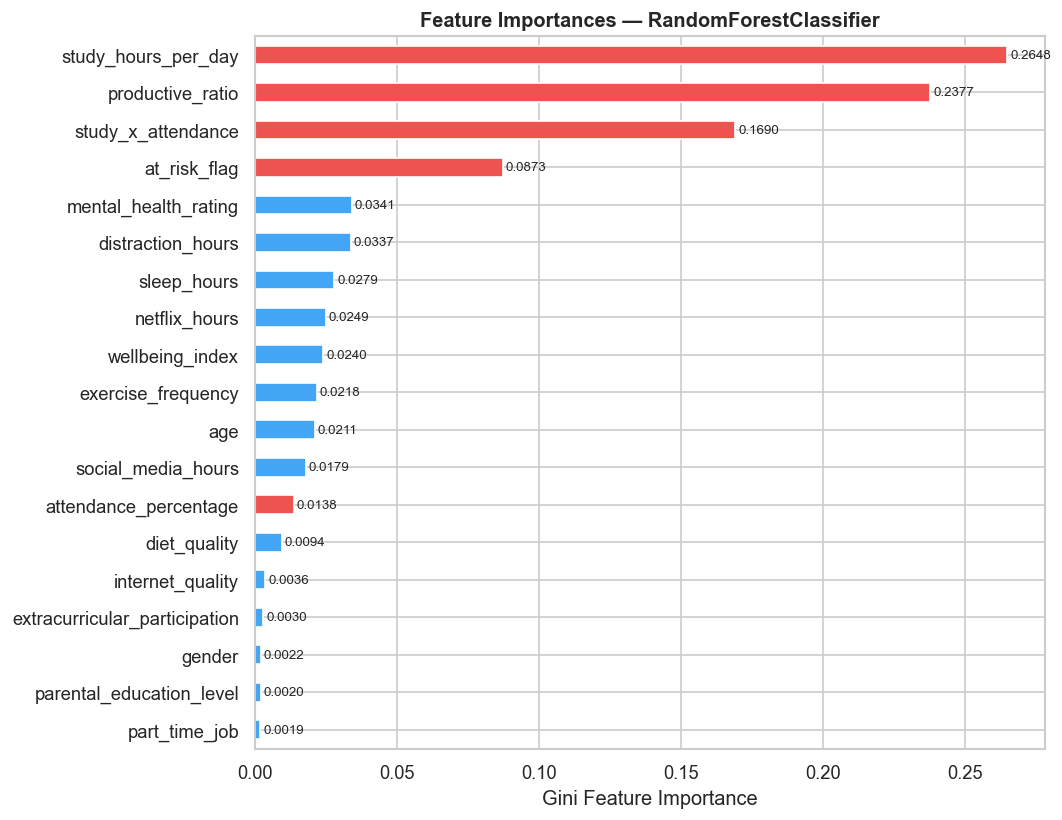

Top 5 features:
study_hours_per_day     0.264755
productive_ratio        0.237667
study_x_attendance      0.169034
at_risk_flag            0.087325
mental_health_rating    0.034087


In [33]:
# ── Built-in Feature Importances ────────────────────────────────
if hasattr(winner, 'feature_importances_'):
    imp = pd.Series(winner.feature_importances_, index=FEATURES).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(9, 7))
    colors = ['#ef5350' if 'study' in f or 'attend' in f or 'risk' in f or 'prod' in f
              else '#42a5f5' for f in imp.index]
    imp.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
    ax.set_xlabel('Gini Feature Importance')
    ax.set_title('Feature Importances — ' + winner_name, fontweight='bold')
    for i, (v, n) in enumerate(zip(imp, imp.index)):
        ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=8)
    plt.tight_layout()
    plt.show()

    print('Top 5 features:')
    print(imp.tail(5).sort_values(ascending=False).to_string())

--- SHAP Summary Plot (Fail class) ---


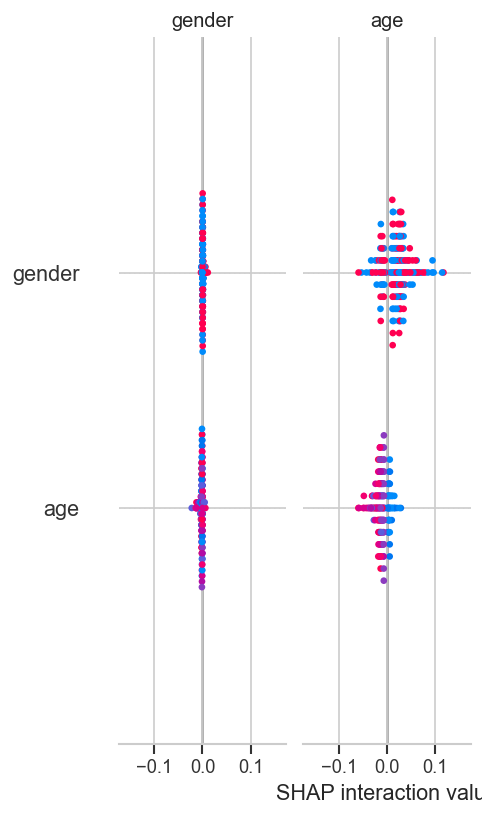


--- SHAP Bar Plot (mean |SHAP|) ---


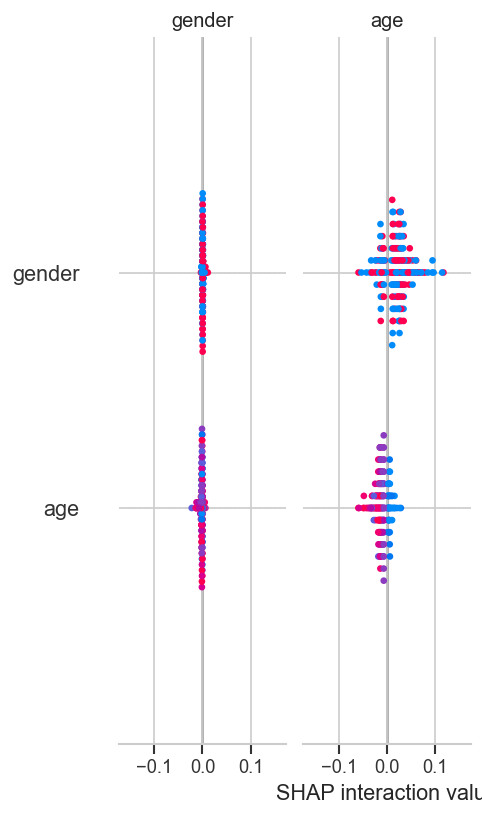

In [34]:
# ── SHAP Analysis ────────────────────────────────────────────────
if HAS_SHAP:
    explainer   = shap.TreeExplainer(winner)
    shap_values = explainer.shap_values(X_test)

    # For RandomForest classifier: shap_values is [fail_shap, pass_shap]
    # Use Fail class (index 0) for at-risk interpretation
    sv_fail = shap_values[0] if isinstance(shap_values, list) else shap_values

    print('--- SHAP Summary Plot (Fail class) ---')
    shap.summary_plot(sv_fail, X_test, feature_names=FEATURES, show=True)

    print('\n--- SHAP Bar Plot (mean |SHAP|) ---')
    shap.summary_plot(sv_fail, X_test, feature_names=FEATURES,
                      plot_type='bar', show=True)
else:
    print('SHAP not installed. Using permutation importance as substitute.')
    perm = permutation_importance(winner, X_test, y_test,
                                  n_repeats=20, random_state=RANDOM_STATE,
                                  scoring='roc_auc')
    perm_imp = pd.Series(perm.importances_mean, index=FEATURES).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(9, 7))
    perm_imp.plot(kind='barh', ax=ax, color='#7986cb', edgecolor='white')
    ax.set_xlabel('Permutation Importance (mean decrease in ROC-AUC)')
    ax.set_title('Permutation Feature Importance', fontweight='bold')
    plt.tight_layout()
    plt.show()

    print('\n  Install shap: pip install shap')
    print('  Then re-run this cell for full SHAP waterfall and summary plots.')

---
## 💾 Section 10 — Retrain on Full Dataset & Save Artefacts

We retrain the selected model on the **entire balanced dataset** (not just the 80% training split) 
to maximise the information available, then save all artefacts needed by `main.py`.

In [35]:
# Retrain winner on full balanced dataset for deployment
X_all_fail = X[y==0]
X_all_pass = X[y==1]
X_fail_up  = resample(X_all_fail, replace=True,
                      n_samples=len(X_all_pass), random_state=RANDOM_STATE)
X_bal_full = pd.concat([X_all_pass, X_fail_up])
y_bal_full = pd.Series([1]*len(X_all_pass) + [0]*len(X_fail_up),
                        index=X_bal_full.index)

winner.fit(X_bal_full, y_bal_full)
print(f'{winner_name} retrained on {len(X_bal_full)} samples')
print(f'Balanced: {int((y_bal_full==0).sum())} Fail + {int((y_bal_full==1).sum())} Pass')

RandomForestClassifier retrained on 1916 samples
Balanced: 958 Fail + 958 Pass


In [36]:
# Save all artefacts
joblib.dump(winner,           'best_model.pkl')
joblib.dump(FEATURES,         'model_features.pkl')
joblib.dump(best_threshold,   'decision_threshold.pkl')
joblib.dump({
    'ordinal_maps':     ORDINAL_MAPS,
    'winsorise_bounds': winsorise_bounds,
    'model_features':   FEATURES,
}, 'preprocessing_artifacts.pkl')

print('✅ Saved artefacts:')
print('   best_model.pkl')
print('   model_features.pkl')
print('   decision_threshold.pkl')
print('   preprocessing_artifacts.pkl')
print(f'\nDecision threshold : {best_threshold:.2f}')
print(f'Model              : {winner_name}')
print(f'Features           : {len(FEATURES)}')
print('\n🚀 Now run:  streamlit run main.py')

✅ Saved artefacts:
   best_model.pkl
   model_features.pkl
   decision_threshold.pkl
   preprocessing_artifacts.pkl

Decision threshold : 0.60
Model              : RandomForestClassifier
Features           : 19

🚀 Now run:  streamlit run main.py


---
## ✅ Summary

| Step | Action | Outcome |
|---|---|---|
| 1 | EDA | Identified key correlates, class imbalance (4.2% Fail), 91 missing values |
| 2 | Preprocessing | Dropped ID, imputed NaN, winsorised 21 outliers, ordinal encoded 6 columns |
| 3 | Fairness Audit (Labels) | Demographic Parity checked across gender and parental education on training labels |
| 4 | Feature Engineering | 5 compound features created; `study_x_attendance` is strongest |
| 5 | Imbalance Fix | RandomOverSampler inside ImbPipeline (leak-free) + `class_weight='balanced'` |
| 6 | Model Training | RF + XGBoost with 5-fold GridSearchCV via ImbPipeline (no CV leakage) |
| 7 | Threshold Tuning | Optimal threshold tuned for Fail F1 (below 0.5) |
| 8 | Evaluation | Classification report, ROC-AUC, confusion matrix |
| 8b | Bootstrap CIs | 1000-resample confidence intervals for Fail Precision/Recall/F1/AUC |
| 8c | Fairness (Predictions) | Demographic Parity + Equalized Odds on model predictions |
| 8d | Dataset Validity | Feature mapping table: synthetic proxy to OULAD equivalents |
| 9 | Explainability | Feature importance + SHAP (if available) |
| 10 | Save | 4 artefacts saved for `main.py` Streamlit dashboard |